# Sparseness-Optimized Feature Iportance (SOFI) applied to Bone Age Assessment (BAA)

*Modified code.
Source:* https://github.com/igraugar/sofi/blob/main/SOFI%20images.ipynb


In [1]:
# !pip3 install pygad
# !pip3 install cmcrameri
# !pip3 install ultralytics
# !pip3 install tensorflow
# !pip3 install scikit-image
# !pip3 install opencv-python
# !pip3 install seaborn
# !pip3 install matplotlib

In [2]:
import os
import cv2
import pygad
import time
import random

import numpy as np

from skimage.draw import polygon
from scipy.ndimage import gaussian_filter

import tensorflow as tf

# # import tensorflow_addons as tfa
# from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.utils import load_img, img_to_array, array_to_img
# from tensorflow.keras.models import Model

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.cm import get_cmap

import seaborn as sns
sns.set(font_scale=1.2, style='white')

import warnings
warnings.simplefilter("ignore")

seed = 1
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
tf.random.set_seed(seed)
np.random.seed(seed)

from cmcrameri import cm

### BAA Model

#### model

In [3]:
import keras
from keras.layers import Layer, Dense, Activation, Multiply, Concatenate, Conv2D, GlobalAveragePooling2D, GlobalMaxPooling2D
import tensorflow as tf

@keras.saving.register_keras_serializable(package="my_package", name="channel_attention_module")
def channel_attention_module(x, ratio=8):
    batch, _, _, channel = x.shape

    ## Shared layers
    l1 = Dense(channel//ratio, activation="relu", use_bias=False)
    l2 = Dense(channel, use_bias=False)

    ## Global Average Pooling
    x1 = GlobalAveragePooling2D()(x)
    x1 = l1(x1)
    x1 = l2(x1)

    ## Global Max Pooling
    x2 = GlobalMaxPooling2D()(x)
    x2 = l1(x2)
    x2 = l2(x2)

    ## Add both the features and pass through sigmoid
    feats = x1 + x2
    feats = Activation("sigmoid")(feats)
    feats = Multiply()([x, feats])

    return feats

@keras.saving.register_keras_serializable(package="MyLayers")
class SpatialAttentionModule(Layer):
    def __init__(self, **kwargs):
        super(SpatialAttentionModule, self).__init__(**kwargs)
        # Initialize the Conv2D layer here
        self.conv_layer = Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")

    def build(self, input_shape):
        # This method is called with the shape of the input tensor(s)
        # It's a good place to create layer weights or define sub-layers
        super(SpatialAttentionModule, self).build(input_shape)

    def call(self, x):
        ## Average Pooling
        x1 = tf.reduce_mean(x, axis=-1)
        x1 = tf.expand_dims(x1, axis=-1)

        ## Max Pooling
        x2 = tf.reduce_max(x, axis=-1)
        x2 = tf.expand_dims(x2, axis=-1)

        ## Concatenat both the features
        feats = Concatenate()([x1, x2])
        ## Conv layer - use the initialized layer
        feats = self.conv_layer(feats)
        feats = Multiply()([x, feats])

        return feats

@keras.saving.register_keras_serializable(package="my_package_cbam", name="cbam")
def cbam(x):
    x = channel_attention_module(x)
    # Use the custom layer
    x = SpatialAttentionModule()(x)
    return x

model = keras.models.load_model(
    "BoneAgeModel-v2.keras",
    custom_objects={"SpatialAttentionModule": SpatialAttentionModule,
                    "channel_attention_module": channel_attention_module,
                    "cbam": cbam}
                    )

In [4]:
# image size for inference
size = (256, 256)

In [5]:
batlow_cmap = cm.batlow

In [6]:
def display_images(image_paths):
    """
    Display images without additional annotations.

    Parameters:
    - image_paths (list): List of file paths to the images to be displayed.

    Returns:
    None

    The function displays images from the provided file paths in a grid layout without any additional
    annotations or predictions. It reads and decodes each image using TensorFlow and displays them
    in a grid.

    Note:
    - The images are displayed in the order they appear in the 'image_paths' list.
    """

    num_images = len(image_paths)
    num_columns = min(4, num_images)
    num_rows = int(np.ceil(num_images / num_columns))

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(3 * num_columns, 3 * num_rows))

    for idx, image in enumerate(image_paths):

        # Read the image using TensorFlow.
        tf_image = tf.io.read_file(image)

        # Decode the above `tf_image` from a Bytes string to a numeric Tensor.
        decoded_image = tf.image.decode_image(tf_image)

        # show image
        ax = axes if num_columns == 1 else axes.flat[idx]
        ax.imshow(decoded_image)
        ax.axis('off')

## Segments (ROIS)

In [7]:
from ultralytics import YOLO

# Load the YOLOv8 model
yolo_model = YOLO('Yolo.pt')

def plot_obbs(img, obb_list, cls):

  img_obbs = img.copy()

  # Define the color map for the categories
  category_color_map = {0:(0,255,108), 1:(0,243,255), 2:(206,0,160), 3:(255,116,223), 4:(249,170,255), 5:(202,86,0),
                        6:(255,120,44), 7:(255,160,120), 8:(6,63,206), 9:(72,121,255), 10:(166,196,255), 11:(199,232,0),
                        12:(244,255,72), 13:(244,255,142), 14:(134,0,255), 15:(166,55,255), 16:(196,139,255), 17:(255,255,255),
                        18:(151,255,169)}
  # Draw points
  for obb_cls in range(len(obb_list)):
      # get index position
      cls_position = cls.index(obb_cls)
      points = obb_list[cls_position]
      cv2.polylines(img_obbs,[points],True, category_color_map[obb_cls])

  plt.imshow(img_obbs)
  plt.axis('off')
  plt.show()


def sort_infered_cls(obb_list, cls):
  """
  Sort cls and obb_list. The inference result in a random order.
  cls: array
  obb_list: array

  Returns:
  obb_list: array
  cls: array
  """
  desired_cls_order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  cls_position = [cls.index(i) for i in desired_cls_order]
  sorted_obb_list = [obb_list[i] for i in cls_position]
  return np.array(sorted_obb_list), desired_cls_order


def yolo_predict(img, model=yolo_model):
    """
    Perform inference using the YOLO
    image: array
    """
    # Perfomr inference
    results = yolo_model(img)

    # Get oriented bounding boxes (obb_list)
    obb_list = results[0].obb.xyxyxyxy.cpu().numpy().astype(int)
    names = results[0].names
    cls = list(results[0].obb.cls.cpu().numpy().astype(int))

    obb_list, cls = sort_infered_cls(obb_list, cls)

    # Show keys
    for key,name in names.items():
        print(key,name)

    plot_obbs(img, obb_list, cls)

    return obb_list, names, cls

<img src="hand_parts.png" width="50%">

In [8]:
def create_mask_from_seg(img, anns, cls_list):
    """
    Create a mask with unique integer labels for each segment based on annotations.

    Parameters:
    - img (dict): A dictionary containing information about the image (e.g., height, width).
    - anns (list): A list of annotations containing segmentation information.
    - cls_list (list): A list of class labels corresponding to the annotations.

    Returns:
    numpy.ndarray: A 2D array representing the mask with unique integer labels for each segment.

    This function generates a mask with unique integer labels for each segment defined by the provided
    annotations. It assumes a single segmentation polygon for each annotation and assigns a unique label
    to each segment in the mask. The resulting mask has the same dimensions as the image.
    """
    # label 1 -
    # label 2 -
    # label 3 - phalange_distal [2,5,8,11,14]
    # label 4 - phalange_middle [3,6,9,12,15]
    # label 5 - phalange_proximal_metacarpus[4,7,10,13,16]
    # label 6 - carpal
    # label 7 - hand+wrist
    # dict_seg_cls consolidate phalange_distal, phalange_middle, and phalange_proximal_metacarpus
    dict_seg_cls = {0:1, 1:2, 2:3, 5:3, 8:3, 11:3, 14:3, 3:4, 6:4, 9:4, 12:4, 15:4, 4:5, 7:5, 10:5, 13:5, 16:5, 17:6, 18:7}

    mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.int32)

    for i in cls_list:
        seg = anns[i]
        # convert seg into pixel coordidinates
        rr, cc = polygon(seg[:,1], seg[:,0])  # Convert polygon to pixel coordinates
        mask[rr, cc] = dict_seg_cls[i]  # Assign a unique label to the segment
    return mask

In [9]:
def display_mask_over_image(img, mask, alpha=1.0, filename=None):

    # Rescale heatmap to a range 0-255
    min_value = np.min(mask)
    max_value = np.max(mask)
    heatmap = np.uint8(255 * (mask - min_value) / (max_value - min_value))

    # Use jet colormap to colorize heatmap
    cmap = batlow_cmap

    # Use RGB values of the colormap
    cmap_colors = cmap(np.arange(256))[:, :3]
    cmap_heatmap = cmap_colors[heatmap]

    # Resize heatmap
    cmap_heatmap = array_to_img(cmap_heatmap)
    cmap_heatmap = cmap_heatmap.resize((img.shape[1], img.shape[0]))
    cmap_heatmap = img_to_array(cmap_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = cmap_heatmap * alpha + img * 0.15
    superimposed_img = array_to_img(superimposed_img)

    plt.figure()
    ps = plt.imshow(superimposed_img, cmap=batlow_cmap)
    cb = plt.colorbar(ps)
    cb.set_ticks([])
    plt.axis('off')
    # plt.show()

    if filename is not None:
        plt.savefig('figures/' + filename + ".pdf", dpi=300, bbox_inches='tight')


## Classification and occlusion plots

In [10]:
def display_blurred_seg_pred(img_array, mask, model, permutation=None, filename=None, sex=100):
    """
    Blurs the image based on the mask, segment by segment, and display the predictions.

    Parameters:
    - img_array (numpy.ndarray): The input image as a NumPy array.
    - mask (numpy.ndarray): The segmentation mask containing unique integer labels.
    - model (tf.keras.Model): The TensorFlow Keras model for prediction.
    - permutation (list, optional): A list specifying the order of segment blurring. Default is None.
    - filename (str, optional): The filename to save the plot. Default is None.
    - sex (int or float, optional): The sex value to be used as input. Default is 100.

    Displays a grid of images where each subplot corresponds to a different segmentation mask.
    The images are created by successively blurring each segment of the input image and
    predicting the bone age using the specified model. The original image is displayed
    in the first subplot, and subsequent subplots show the effects of blurring each segment individually.
    """

    num_segments = np.max(mask)  # Assuming mask contains unique integer labels
    if permutation is None:
        permutation = list(range(1, num_segments + 1)) # Start from 1 to exclude background
    segment_list = [-1] + permutation # -1 for the original (no changes in mask)

    # Create a copy of the original image array to modify within the loop
    original_image_np = img_array.copy().astype(np.float32)

    num_images = len(segment_list)

    # for the leopard figures
    num_columns = min(3, num_images)
    #
    # for appendices
#     num_columns = min(1, num_images)
    #

    num_rows = int(np.ceil(num_images / num_columns))

    # for the leopard figures
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(6 * num_columns, 6 * num_rows))
    #
    # for appendices
#     fig, axes = plt.subplots(num_rows, num_columns, figsize=(2 * num_columns, 2 * num_rows))
    #

    # Resize original image for model input once
    image_resized_for_model = tf.image.resize(original_image_np, size)

    # Predict the baseline bone age using the original image
    ref_prediciton = model.predict((np.array([image_resized_for_model/255.0]), np.array([sex])))
    ref_prediciton_years = ref_prediciton[0][0] * 18 # Assuming prediction is in years directly

    current_image_np = original_image_np.copy() # Initialize the image for blurring

    for idx, segment_label in enumerate(segment_list):

        if segment_label == -1:
            # Display the original image and its baseline prediction
            display_image = original_image_np.astype('uint8')
            score = 0.00
            label_to_display = ref_prediciton_years
        else:
            # Create a mask for the current segment
            segment_mask_bool = (mask == segment_label)

            # Ensure the boolean mask has 3 channels to match the image
            segment_mask_bool_3channel = np.stack([segment_mask_bool] * 3, axis=-1)

            # Create Gaussian blur of the current segment
            # Blur only the segment area on the original image
            blurred_segment_only = np.zeros_like(original_image_np)
            blurred_segment_only[segment_mask_bool_3channel] = gaussian_filter(original_image_np, sigma=2)[segment_mask_bool_3channel]

            # Update the image for display by replacing the segment with its blurred version
            current_image_np = np.where(segment_mask_bool_3channel, blurred_segment_only, current_image_np)
            display_image = current_image_np.astype('uint8')


            # Convert the updated image back to a TensorFlow tensor and resize for the model
            decoded_image = tf.convert_to_tensor(current_image_np)
            image_resized_for_model = tf.image.resize(decoded_image, size)

            # Predict with the modified image
            decoded_preds = model.predict((np.array([image_resized_for_model/255.0]), np.array([sex])))
            decoded_preds_years = decoded_preds[0][0] * 18 # Assuming prediction is in years directly

            score = abs(decoded_preds_years - ref_prediciton_years)
            label_to_display = ref_prediciton_years # Still display the baseline label


        ax = axes.flat[idx]
        ax.imshow(display_image)


        title = str('{:.2f}'.format(score))
        ax.set_title(title, fontsize=12) # Reduced font size for better readability
        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
        if idx == 0: # Only add y-axis label to the first subplot
            ax.set_ylabel(f"Baseline: {label_to_display:.2f} years", fontsize=12) # Added label for clarity


    [fig.delaxes(ax) for ax in axes.flatten() if not ax.has_data()] # removing empty subplots
    plt.tight_layout() # Adjust layout to prevent titles overlapping

    if filename is not None:
        plt.savefig('figures/' + filename + ".pdf", dpi=300, bbox_inches='tight')

## GA feature importance curves

In [11]:
def model_predict(img, sex=100, model=model):
    """
    Predict the class label for a given image using the specified model.

    Parameters:
    - image (numpy.ndarray or tf.Tensor): The input image to be predicted. Should have a batch dimension.
    - model (tf.keras.Model): The TensorFlow Keras model for prediction.
    - sex (int or float): The sex value to be used as input. Default is 100.

    Returns:
    numpy.ndarray: The predicted class label for the input image.

    This function preprocesses the input image and uses the specified model to predict
    the class label. The predicted label is returned as a NumPy array.
    """

    # Predict the class label
    prediction = model.predict((np.array([img/255.0]), np.array([sex])))

    return prediction[0][0]


def fit_value(img, mask, model, permutation, size=(256, 256), lambda_penalty=1.2, sex=100):
    """
    Compute the AUC and points for the feature flipping curve associated with a permutation.

    Parameters:
    - img (dict): Information about the image, including the file name.
    - mask (numpy.ndarray): The segmentation mask associated with the image.
    - model (tf.keras.Model): The TensorFlow Keras model for prediction.
    - permutation (list): The permutation used for feature flipping.

    Returns:
    tuple: A tuple containing the fitness value and the list of values.

    This function computes the area under the curve (AUC) and values for the feature flipping curve
    associated with the given permutation. It performs feature flipping by progressively blurring
    image segments based on the permutation, predicts the modified images, and calculates the AUC
    along with the values for the specified target label. The fitness value is a combination of the
    AUC and a penalty term for non-monotonic changes in the values.
    """

    # Check img size
    if img.shape[:2] != size:
        img = cv2.resize(img, size)


    # Model g_0 prediction. This is the reference.
    baseline_score = model_predict(img, sex)


    # Weights w for the position of each element and g_value is the bone age list
    w = np.array(range(len(permutation),0,-1)) #/len(permutation)

    # w_inv_exp = np.power(12, np.array(range(1,len(permutation))))
    # w_inv_exp =  w_inv_exp / np.sum(w_inv_exp)

    w_inv_exp = np.power(lambda_penalty, np.array(range(1,len(permutation))))

    g_values = []
    predictions =[]

    for segment_label in permutation:

        # Create a mask for the current segment
        segment_mask = (mask == segment_label)

        # Resize the segment mask to match the image shape
        # Resize the boolean mask to the target size (256, 256)
        segment_mask_resized = tf.image.resize(
            tf.cast(segment_mask, tf.float32)[..., tf.newaxis], size
        )
        # Convert back to boolean, thresholding at a small value
        segment_mask_resized_bool = segment_mask_resized > 0.5

        # Ensure the boolean mask has 3 channels to match image_np
        resized_segment_mask = tf.broadcast_to(segment_mask_resized_bool, tf.shape(img))


        # Create Gaussian blur and update the original image with the blurred segment
        blurred_segment = gaussian_filter(img, sigma=2)
        # Use the resized boolean mask for the where condition
        image_blurred = np.where(resized_segment_mask, blurred_segment, img)

        # Pre-process and predict the input image.
        # Pass image_batch and sex_input as separate arguments
        score = model_predict(image_blurred, sex)

        # Error list
        g_values.append(np.abs(score-baseline_score))

    # Calculate the area under the curve based on the values
    # The AUC calculation and fitness function logic might need adjustment depending on
    # the intended interpretation of 'feature importance' for regression tasks like Bone Age.
    # The original code calculates AUC based on the *decrease* in prediction score.
    # For a regression model, a significant *change* in the prediction when blurring a feature
    # indicates importance. The direction (increase or decrease) might matter depending on
    # whether a lower or higher predicted age is considered 'better'.
    # For now, let's stick to the original logic of weighted sum.
    area_under_curve = np.sum(w * g_values)

    # Change/invert g_values order to calculate penalty
    inverted_g_values = np.array(g_values)[::-1]

    # Fitness function
    fitness = (area_under_curve - np.sum(w_inv_exp * np.maximum(np.diff(inverted_g_values), 0))) # Penalize non-monotonic decrease

    return fitness, g_values

In [12]:
def fitness_func(ga_instance, solution, solution_idx):
    """
    Fitness function for a genetic algorithm.

    Parameters:
    - ga_instance (pygad.GA): The genetic algorithm instance.
    - solution (list): The solution representing a permutation.
    - solution_idx (int): The index of the solution in the population.

    Returns:
    float: The fitness value for the given solution.

    This function evaluates the fitness of a solution (permutation) for a genetic algorithm. It
    calls the `fit_value` function to compute the AUC and values for the feature flipping curve
    associated with the solution and then calculates the fitness as the reciprocal of the AUC
    for maximization.
    """

    # The label variable is likely the baseline prediction value for this image.
    # We need to make sure 'label' is correctly passed and used if needed,
    # but the current implementation of fit_value doesn't directly use 'label' for the score.
    # It calculates scores based on the model's prediction on the progressively blurred images.
    auc, _ = fit_value(img, mask, model, solution)

    # The fitness is the reciprocal of the AUC. If AUC approaches 0, fitness goes to infinity.
    # This is for maximization.
    # Depending on the AUC calculation (weighted sum of scores), a higher AUC might mean
    # the prediction stays high even when blurring segments. If the goal is to find segments
    # that cause the *largest drop* in prediction when blurred, the fitness might need to be
    # based on the *change* from the baseline prediction.
    # fitness = 1.0 / (auc/12 + 0.000001) # for maximization (times 12 months)
    fitness = auc # for maximization
    return fitness

In [13]:
def plot_feature_flipping(method_names, g_values_list, filename=None, roi_labels=None):
    """
    Plot the feature flipping curves for multiple methods.

    Parameters:
    - method_names (list): List of method names for labeling the curves.
    - g_values_list (list): List of lists containing G-values for each method.
    - roi_labels (list, optional): Labels for each dot, one per ROI in sequence order.

    This function generates a plot visualizing feature flipping curves for different methods.
    It takes a list of method names and their corresponding G-values and creates a line plot,
    where each curve represents a method. The x-axis represents the feature flipping index,
    and the y-axis represents the associated G-values. The area under the curves is filled with grey.

    Example:
    ```python
    method_names = ['Method A', 'Method B']
    g_values_list = [[0.5, 0.7, 0.6], [0.3, 0.4, 0.5]]
    plot_feature_flipping(method_names, g_values_list)
    plt.show()
    ```
    """
    fig, ax = plt.subplots()
    for idx, method in enumerate(method_names):

        g_values = g_values_list[idx]

        x_data = np.array(range(1, len(g_values)+1))

        ax.plot(x_data, g_values, marker='o',
                markersize=10, linestyle='--', color='0.2', markerfacecolor=sns.color_palette()[idx], label=method)

        if roi_labels is not None:
            for xi, yi, lbl in zip(x_data, g_values, roi_labels):
                ax.annotate(
                    lbl, (xi, yi),
                    textcoords='offset points', xytext=(-2, 5),
                    ha='center', fontsize=10, rotation=30,
                )

    ax.set_xlabel('$\pi_i$')
    ax.set_ylabel('$g(\pi_i)$')
    ax.legend(fontsize=10)

    # Fill the area under the curve with grey
    ax.fill_between(x_data, np.min(g_values), g_values,
                    where=(g_values >= np.min(g_values)), color='grey', alpha=0.2)

    # Expand top of y-axis so rotated labels stay inside the axes frame
    if roi_labels is not None:
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.25)

    if filename is not None:
        plt.savefig('./results/' + filename + ".png", dpi=600, bbox_inches='tight')

In [14]:
def create_ga_score_mask(segment_mask, best_permutation, ga_values):

    p_list = list(best_permutation)

    # Get the unique segment IDs from the segment_mask
    unique_segments = [s for s in np.unique(segment_mask) if s != 0]

    # Create an empty mask to store the average importance for each segment
    ga_score_mask = np.zeros_like(segment_mask, dtype=float)

    # Calculate the mean score for each segment
    for segment_id in unique_segments:

        # Mask for the current segment
        segment_mask_bool = (segment_mask == segment_id)

        # Compute score
        ga_score = ga_values[p_list.index(segment_id)]

        # Fill the corresponding region in the mean_score_mask
        ga_score_mask = ga_score_mask * (1 - segment_mask_bool) + ga_score * segment_mask_bool

    return ga_score_mask

In [15]:
_DEFAULT_ROI_NAMES = {
    1: 'Ulna',
    2: 'Radius',
    3: 'Distal Ph.',
    4: 'Middle Ph.',
    5: 'Prox. Ph. \n& Metacarpus',
    6: 'Hand & \nWrist',
    7: 'Carpal',
}

def plot_degradation_curve(roi_sequence, img, mask, model, sex=100, label='Degradation curve', filename=None, roi_names=None):
    """
    Compute and plot the degradation curve for a given ROI sequence.

    Parameters:
    - roi_sequence (list): Ordered list of ROI/segment indices to progressively blur.
    - img (numpy.ndarray): Input image.
    - mask (numpy.ndarray): Segmentation mask with integer labels matching roi_sequence values.
    - model (tf.keras.Model): Bone age prediction model.
    - sex (int or float): Sex input for the model. Default is 100.
    - label (str): Legend label for the curve. Default is 'SOFI'.
    - filename (str, optional): If provided, saves the plot to ./results/<filename>.png.
    - roi_names (dict, optional): Mapping from ROI index to display name. Defaults to
      {1:'Radius', 2:'Ulna', 3:'Distal Ph.', 4:'Middle Ph.', 5:'Prox./Meta.', 6:'Carpal', 7:'Hand+Wrist'}.

    Example:
    ```python
    plot_degradation_curve([3, 1, 5, 2, 7, 4, 6], img, mask, model, sex=100)
    plt.show()
    ```
    """
    name_map = roi_names if roi_names is not None else _DEFAULT_ROI_NAMES
    dot_labels = [name_map.get(r, str(r)) for r in roi_sequence]
    _, g_values = fit_value(img, mask, model, roi_sequence, sex=sex)
    plot_feature_flipping([label], [g_values], filename=filename, roi_labels=dot_labels)
    plt.show()

## Load Dataset

In [16]:
import pickle

# load pckl dataset
with open('./Data/X.pkl', 'rb') as f:
    dataset = pickle.load(f)

with open('./Data/y.pkl', 'rb') as f:
    y = pickle.load(f)

for fold in range(5):
  for i in range(len(dataset[fold])):
    if dataset[fold][i][1] == 'F':
      dataset[fold][i][1] = 100
    else:
      dataset[fold][i][1] = 200

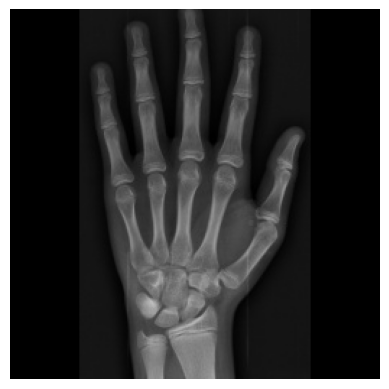


0: 512x512 1 ulna, 1 radius, 1 phalange_distal_I, 1 phalange_proximal_I, 1 metacarpus_I, 1 phalange_distal_III, 1 phalange_middle_III, 1 phalange_proximal_metacarpus_III, 1 phalange_distal_V, 1 phalange_middle_V, 1 phalange_proximal_metacarpus_V, 1 phalange_distal_II, 1 phalange_proximal_II, 1 phalange_proximal_metacarpus_II, 1 phalange_distal_IV, 1 phalange_proximal_IV, 1 phalange_proximal_metacarpus_IV, 1 hand+wrist, 1 carpal, 31.1ms
Speed: 1.6ms preprocess, 31.1ms inference, 2.4ms postprocess per image at shape (1, 3, 512, 512)
0 ulna
1 radius
2 phalange_distal_I
3 phalange_proximal_I
4 metacarpus_I
5 phalange_distal_III
6 phalange_middle_III
7 phalange_proximal_metacarpus_III
8 phalange_distal_V
9 phalange_middle_V
10 phalange_proximal_metacarpus_V
11 phalange_distal_II
12 phalange_proximal_II
13 phalange_proximal_metacarpus_II
14 phalange_distal_IV
15 phalange_proximal_IV
16 phalange_proximal_metacarpus_IV
17 hand+wrist
18 carpal


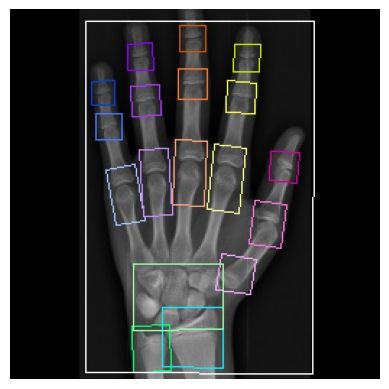

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


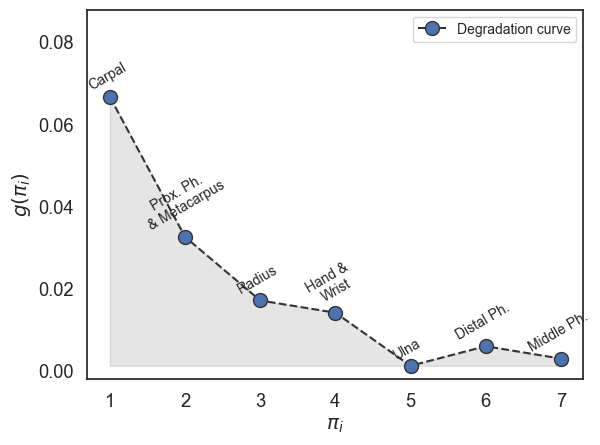

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


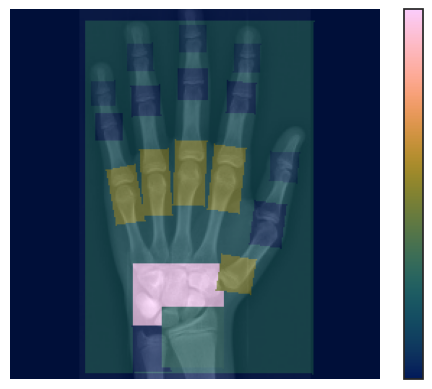

In [49]:
n_img = 58

fold = 1
img, sex = dataset[fold][n_img]
sequence = [7, 5, 2, 6, 1, 3, 4]

plt.imshow(img)
plt.axis('off')
# no background
plt.show()

#Get obb using Yolo
obb_list, names, cls = yolo_predict(img)

# check and fix obb coordinates
obb_list[obb_list>255]=255
obb_list[obb_list<0]=0

# testing mask
# Reorder anns based on the specified order
cls_plot_order = [17, 18, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
cls_position = [cls.index(i) for i in cls_plot_order]
anns = obb_list
mask = create_mask_from_seg(img, anns, cls_plot_order)

plot_degradation_curve(sequence, img, mask, model, sex=sex)
plt.show()

# Heatmap for the leopard figure
_, ga_values = fit_value(img, mask, model, sequence, sex=sex)
ga_score_mask = create_ga_score_mask(mask, sequence, ga_values)

display_mask_over_image(img, ga_score_mask, alpha=0.2, filename=f"{n_img}_{sex}_sofi_mask")
